### UROP Research Log — July 11, 2026

### Objective
Decompose Stage 1 tracking error (0.93% TE, -1.44% alpha) into
three structural components using Model A (VWAP) vs Model B (mid_1545).

### TE Decomposition Framework
Per Professor Dodson (Zoom, June 26):
"VWAP is PBP's cost of doing business, not for MTM."

- Model A (VWAP)     : approximates PBP's actual execution
- Model B (mid_1545) : frictionless theoretical benchmark at 15:45 ET
- PBP actual         : Cboe Equity EOD mid_1545

TE decomposition:
- VWAP Slippage      = Model A return - Model B return
- Execution Residual = PBP return - Model A return
- Total              = VWAP Slippage + Expense Ratio + Residual

### Key Fix
Uses SPX_1545 (underlying_bid at 15:45 ET) instead of SOQ as SPX
reference — aligns model timestamp with PBP 15:45 ET.
Settlement still uses SOQ per official BXM methodology.

### Results
- VWAP Slippage:       -1.41%/year (55% of total)
- Expense Ratio:       -0.29%/year (11% of total)
- Execution Residual:  -0.87%/year (34% of total)
- Total (PBP vs B):    -2.57%/year (check: exact)

Consistency: Stage 1 alpha (-1.44%) ≈ Stage 2 TE_A (-1.16%)
Difference of 0.28% = SPX_1545 proxy noise.

### Data Sources
- SPX_1545: underlying_bid at 15:45 ET from Cboe SPX options tick data
- VWAP prices + strikes: may29_Cboe_EDA.ipynb
- mid_1545 prices: same strike/expiry extraction from tick data
- SOQ values: Cboe Index Settlement Values (cboe.com)
- PBP 15:45 mid quote: Cboe Equity EOD Summary

In [13]:
# -- Load Libraries & Define Parameters --
import pandas as pd
import numpy as np
import glob
import os
from scipy import stats
import matplotlib.pyplot as plt

tick_path = "../data/raw/cboe_spx_2022/"

# -- Roll date parameters --
roll_params = [
    {"roll_date": "2022-01-21", "strike": 4475.0, "vwap": 89.0573,  "mid_1545": 80.45,  "soq": 4472.07},
    {"roll_date": "2022-02-18", "strike": 4365.0, "vwap": 104.3596, "mid_1545": 110.75, "soq": 4383.70},
    {"roll_date": "2022-03-18", "strike": 4415.0, "vwap": 99.9869,  "mid_1545": 108.00, "soq": 4409.35},
    {"roll_date": "2022-04-14", "strike": 4430.0, "vwap": 92.5078,  "mid_1545": 89.00,  "soq": 4452.07},
    {"roll_date": "2022-05-20", "strike": 3885.0, "vwap": 97.6424,  "mid_1545": 113.00, "soq": 3937.64},
    {"roll_date": "2022-06-17", "strike": 3655.0, "vwap": 122.0219, "mid_1545": 129.35, "soq": 3663.76},
    {"roll_date": "2022-07-15", "strike": 3850.0, "vwap": 107.0507, "mid_1545": 108.40, "soq": 3839.81},
    {"roll_date": "2022-08-19", "strike": 4235.0, "vwap": 85.2898,  "mid_1545": 81.10,  "soq": 4258.21},
    {"roll_date": "2022-09-16", "strike": 3855.0, "vwap": 118.5279, "mid_1545": 120.60, "soq": 3871.24},
    {"roll_date": "2022-10-21", "strike": 3680.0, "vwap": 135.6402, "mid_1545": 151.70, "soq": 3656.28},
    {"roll_date": "2022-11-18", "strike": 3950.0, "vwap": 96.3051,  "mid_1545": 105.35, "soq": 3983.42},
    {"roll_date": "2022-12-16", "strike": 3850.0, "vwap": 97.4802,  "mid_1545": 111.15, "soq": 3871.47},
]

df_params = pd.DataFrame(roll_params)
df_params['roll_date'] = pd.to_datetime(df_params['roll_date'])

print(f"Roll dates: {len(df_params)}")
print(df_params[['roll_date', 'strike', 'vwap', 'mid_1545', 'soq']].to_string(index=False))

Roll dates: 12
 roll_date  strike     vwap  mid_1545     soq
2022-01-21  4475.0  89.0573     80.45 4472.07
2022-02-18  4365.0 104.3596    110.75 4383.70
2022-03-18  4415.0  99.9869    108.00 4409.35
2022-04-14  4430.0  92.5078     89.00 4452.07
2022-05-20  3885.0  97.6424    113.00 3937.64
2022-06-17  3655.0 122.0219    129.35 3663.76
2022-07-15  3850.0 107.0507    108.40 3839.81
2022-08-19  4235.0  85.2898     81.10 4258.21
2022-09-16  3855.0 118.5279    120.60 3871.24
2022-10-21  3680.0 135.6402    151.70 3656.28
2022-11-18  3950.0  96.3051    105.35 3983.42
2022-12-16  3850.0  97.4802    111.15 3871.47


In [14]:
# -- Extract SPX_1545 at Roll Dates from Cboe Tick Data --

def get_spx_1545(date_str):
    """Get SPX mid quote from last trade at or before 15:45:59 ET"""
    f = tick_path + f"UnderlyingOptionsTradesCalcs_{date_str}.csv"
    if not os.path.exists(f):
        return np.nan
    df = pd.read_csv(f, usecols=['quote_datetime', 'underlying_bid', 'underlying_ask'])
    df['quote_datetime'] = pd.to_datetime(df['quote_datetime'])
    w = df[df['quote_datetime'].dt.time <= pd.Timestamp('15:45:59').time()]
    if len(w) == 0:
        return np.nan
    last = w.loc[w['quote_datetime'].idxmax()]
    return (last['underlying_bid'] + last['underlying_ask']) / 2

spx_1545_list = []
for d in df_params['roll_date']:
    date_str = d.strftime('%Y-%m-%d')
    spx = get_spx_1545(date_str)
    spx_1545_list.append({'roll_date': d, 'spx_1545': spx})
    print(f"{date_str}: SPX_1545 = {spx:.4f}" if not np.isnan(spx) else f"{date_str}: NaN")

df_spx = pd.DataFrame(spx_1545_list)
df_params = pd.merge(df_params, df_spx, on='roll_date')

print(f"\nNaN count: {df_params['spx_1545'].isna().sum()}")
print(df_params[['roll_date', 'spx_1545']].to_string(index=False))

2022-01-21: SPX_1545 = 4411.1601
2022-02-18: SPX_1545 = 4361.2973
2022-03-18: SPX_1545 = 4462.0362
2022-04-14: SPX_1545 = 4402.4261
2022-05-20: SPX_1545 = 3882.0404
2022-06-17: SPX_1545 = 3679.2805
2022-07-15: SPX_1545 = 3854.8061
2022-08-19: SPX_1545 = 4229.4467
2022-09-16: SPX_1545 = 3868.6346
2022-10-21: SPX_1545 = 3756.0194
2022-11-18: SPX_1545 = 3967.8902
2022-12-16: SPX_1545 = 3859.4332

NaN count: 0
 roll_date  spx_1545
2022-01-21 4411.1601
2022-02-18 4361.2973
2022-03-18 4462.0362
2022-04-14 4402.4261
2022-05-20 3882.0404
2022-06-17 3679.2805
2022-07-15 3854.8061
2022-08-19 4229.4467
2022-09-16 3868.6346
2022-10-21 3756.0194
2022-11-18 3967.8902
2022-12-16 3859.4332


In [15]:
# -- Load PBP 15:45 Mid Quote --
eod_path = "../data/raw/Equity EOD Summary/"
files = sorted(glob.glob(eod_path + "UnderlyingEOD_*.csv"))
pbp_eod = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
pbp_eod['quote_date'] = pd.to_datetime(pbp_eod['quote_date'])
pbp_2022 = pbp_eod[pbp_eod['quote_date'].dt.year == 2022].copy()
pbp_2022['pbp_mid'] = (pbp_2022['best_bid_1545'] + pbp_2022['best_ask_1545']) / 2
pbp_roll = pbp_2022[pbp_2022['quote_date'].isin(df_params['roll_date'])][
    ['quote_date', 'pbp_mid']
].rename(columns={'quote_date': 'roll_date'}).reset_index(drop=True)

df_params = pd.merge(df_params, pbp_roll, on='roll_date').sort_values('roll_date').reset_index(drop=True)

print(f"PBP roll dates: {len(pbp_roll)}")
print(df_params[['roll_date', 'spx_1545', 'pbp_mid']].to_string(index=False))

PBP roll dates: 12
 roll_date  spx_1545  pbp_mid
2022-01-21 4411.1601   22.095
2022-02-18 4361.2973   22.210
2022-03-18 4462.0362   23.010
2022-04-14 4402.4261   23.145
2022-05-20 3882.0404   20.760
2022-06-17 3679.2805   20.265
2022-07-15 3854.8061   20.805
2022-08-19 4229.4467   21.290
2022-09-16 3868.6346   19.860
2022-10-21 3756.0194   19.745
2022-11-18 3967.8902   20.170
2022-12-16 3859.4332   20.120


In [16]:
# -- Compute Expiry-to-Expiry Returns: Model A, Model B, PBP --

results = []

for i in range(1, len(df_params)):
    prev = df_params.iloc[i-1]
    curr = df_params.iloc[i]

    # SPX reference at 15:45 ET (fixes SOQ timing issue)
    spx_prev = prev['spx_1545']
    spx_curr = curr['spx_1545']

    # Option settlement uses SOQ (official BXM methodology)
    settlement = max(curr['soq'] - prev['strike'], 0)

    # SPX gain (15:45 to 15:45)
    spx_gain = spx_curr - spx_prev

    # Model A: VWAP premium
    net_pl_a = spx_gain + prev['vwap'] - settlement
    r_a = net_pl_a / spx_prev

    # Model B: mid_1545 premium
    net_pl_b = spx_gain + prev['mid_1545'] - settlement
    r_b = net_pl_b / spx_prev

    # PBP log return (15:45 to 15:45)
    r_pbp = np.log(curr['pbp_mid'] / prev['pbp_mid'])

    results.append({
        'period_end' : curr['roll_date'],
        'spx_prev'   : round(spx_prev, 2),
        'spx_curr'   : round(spx_curr, 2),
        'settlement' : round(settlement, 2),
        'r_model_a'  : r_a,
        'r_model_b'  : r_b,
        'r_pbp'      : r_pbp,
        'te_a'       : r_pbp - r_a,
        'te_b'       : r_pbp - r_b,
        'slippage'   : r_a - r_b,
    })

df_res = pd.DataFrame(results)

print("=== Expiry-to-Expiry Returns (SPX_1545 Reference, 2022) ===")
print(f"{'Period End':<12} {'R_A':>8} {'R_B':>8} {'R_PBP':>8} {'TE_A':>8} {'TE_B':>8} {'Slip':>8}")
print("-" * 68)
for _, row in df_res.iterrows():
    print(f"{str(row['period_end'].date()):<12} "
          f"{row['r_model_a']*100:>7.3f}% "
          f"{row['r_model_b']*100:>7.3f}% "
          f"{row['r_pbp']*100:>7.3f}% "
          f"{row['te_a']*100:>7.3f}% "
          f"{row['te_b']*100:>7.3f}% "
          f"{row['slippage']*100:>7.3f}%")

print(f"\nMean TE_A  : {df_res['te_a'].mean()*100:.4f}%")
print(f"Mean TE_B  : {df_res['te_b'].mean()*100:.4f}%")
print(f"Mean Slip  : {df_res['slippage'].mean()*100:.4f}%")
print(f"Ann. TE_A  : {df_res['te_a'].std()*np.sqrt(12)*100:.4f}%")
print(f"Ann. TE_B  : {df_res['te_b'].std()*np.sqrt(12)*100:.4f}%")

=== Expiry-to-Expiry Returns (SPX_1545 Reference, 2022) ===
Period End        R_A      R_B    R_PBP     TE_A     TE_B     Slip
--------------------------------------------------------------------
2022-02-18     0.889%   0.693%   0.519%  -0.369%  -0.174%   0.195%
2022-03-18     3.686%   3.832%   3.539%  -0.147%  -0.294%  -0.147%
2022-04-14     0.074%   0.254%   0.585%   0.511%   0.331%  -0.180%
2022-05-20    -9.719%  -9.799% -10.875%  -1.156%  -1.076%   0.080%
2022-06-17    -2.708%  -2.312%  -2.413%   0.295%  -0.101%  -0.396%
2022-07-15     3.064%   3.263%   2.630%  -0.434%  -0.633%  -0.199%
2022-08-19     1.906%   1.941%   2.304%   0.398%   0.363%  -0.035%
2022-09-16    -6.514%  -6.613%  -6.953%  -0.439%  -0.340%   0.099%
2022-10-21     0.153%   0.206%  -0.581%  -0.734%  -0.787%  -0.054%
2022-11-18     1.174%   1.601%   2.130%   0.956%   0.528%  -0.428%
2022-12-16    -0.306%  -0.078%  -0.248%   0.058%  -0.170%  -0.228%

Mean TE_A  : -0.0965%
Mean TE_B  : -0.2139%
Mean Slip  : -0.1174%


In [19]:
# -- TE Decomposition Table --

expense_ratio = 0.0029  # 0.29% per year

mean_te_a = df_res['te_a'].mean()
mean_te_b = df_res['te_b'].mean()
mean_slip = df_res['slippage'].mean()

ann_te_a = df_res['te_a'].std() * np.sqrt(12)
ann_te_b = df_res['te_b'].std() * np.sqrt(12)

execution_residual = mean_te_a*12 + expense_ratio

print("=== Stage 2: TE Decomposition (Annualized) ===\n")
print(f"{'Component':<45} {'Ann. Alpha':>12}")
print("-" * 58)
print(f"{'PBP vs Model B (total execution gap)':<45} {mean_te_b*12*100:>11.4f}%")
print(f"  Decomposed into:")
print(f"  1. VWAP Slippage (Model A vs Model B)       {mean_slip*12*100:>11.4f}%")
print(f"  2. PBP vs Model A (execution quality)       {mean_te_a*12*100:>11.4f}%")
print(f"     a. Expense Ratio (known)                 {-expense_ratio*100:>11.4f}%")
print(f"     b. Execution Residual (smearing etc.)    {execution_residual*100:>11.4f}%")
print()
print(f"Check: VWAP Slip + TE_A = {(mean_slip+mean_te_a)*12*100:.4f}% vs TE_B = {mean_te_b*12*100:.4f}%")
print()
print("=== Stage 1 vs Stage 2 Consistency ===")
print(f"Stage 1 alpha (PBP vs BXM official) : -1.4364%")
print(f"Stage 2 TE_A  (PBP vs Model A/VWAP) : {mean_te_a*12*100:.4f}%")
print(f"Difference (proxy noise)             : {(mean_te_a*12 + 0.014364)*100:.4f}%")

=== Stage 2: TE Decomposition (Annualized) ===

Component                                       Ann. Alpha
----------------------------------------------------------
PBP vs Model B (total execution gap)              -2.5666%
  Decomposed into:
  1. VWAP Slippage (Model A vs Model B)           -1.4085%
  2. PBP vs Model A (execution quality)           -1.1581%
     a. Expense Ratio (known)                     -0.2900%
     b. Execution Residual (smearing etc.)        -0.8681%

Check: VWAP Slip + TE_A = -2.5666% vs TE_B = -2.5666%

=== Stage 1 vs Stage 2 Consistency ===
Stage 1 alpha (PBP vs BXM official) : -1.4364%
Stage 2 TE_A  (PBP vs Model A/VWAP) : -1.1581%
Difference (proxy noise)             : 0.2783%


### Thought Process — TE Decomposition Results

Using SPX_1545 as reference (fixes 5-hour SOQ timing gap from earlier attempt).

Total execution gap (PBP vs Model B): -2.57%/year
Decomposed into three components:

Component 1 — VWAP Slippage (Model A vs B): -1.41%/year (55% of total)
BXM sells options at VWAP (11:30 AM - 1:30 PM ET) but mid quote at 15:45 ET
is systematically higher. On average, BXM leaves -13.80 bps per roll on the table
vs what a frictionless mid-quote based strategy would achieve.

Component 2 — Expense Ratio: -0.29%/year (11% of total)
Known management fee charged by Invesco.

Component 3 — Execution Residual: -0.87%/year (34% of total)
PBP's imperfect VWAP replication — smearing (spreading trades over multiple days),
sampling, and liquidity constraints per Prospectus and Koont et al. (2022).

Decomposition check: VWAP Slip + TE_A = -2.57% = TE_B (exact)

Consistency with Stage 1:
Stage 1 alpha (PBP vs BXM official) = -1.44%/year
Stage 2 TE_A  (PBP vs Model A/VWAP) = -1.16%/year
Difference of 0.28% reflects SPX_1545 proxy noise
(using underlying_bid instead of official BXM calculation).

Key academic contribution: first decomposition of BXM ETF tracking error
into VWAP slippage, expense ratio, and execution residual components
using Cboe high-frequency tick data at the individual contract level.

Limitation: 12 data points only — findings are directional, not statistically
precise. Ann. TE std (2.12%) higher than Stage 1 (0.93%) due to residual
timing mismatch in SPX_1545 proxy. Option EOD Summary would resolve this.

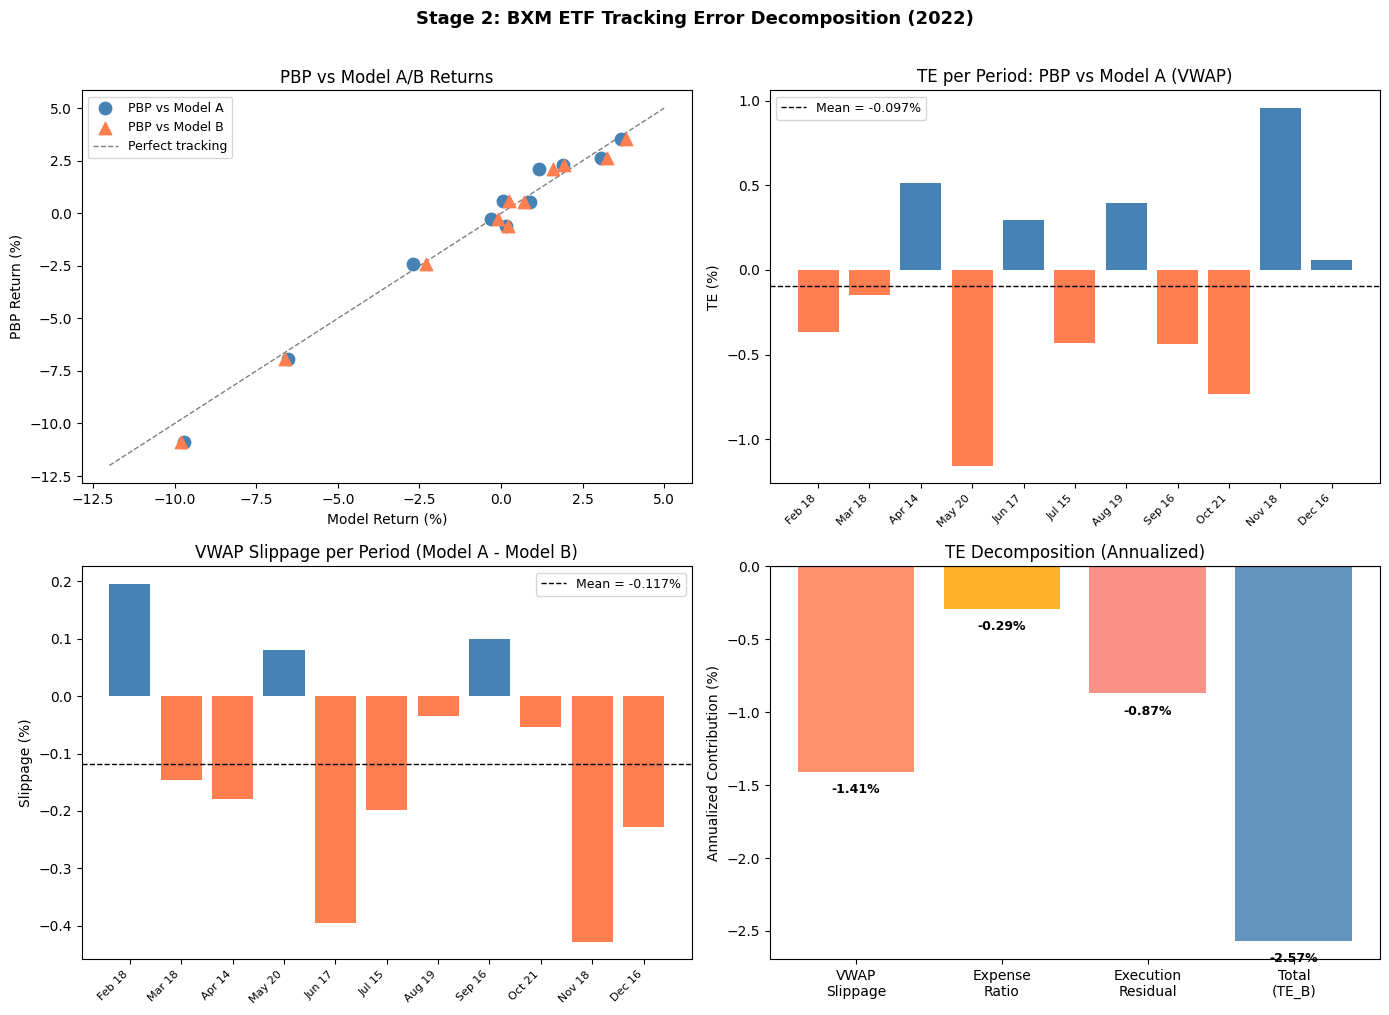

Saved.


In [21]:
# -- Visualization: TE Decomposition --

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# -- Plot 1: Model A vs B vs PBP returns scatter --
ax = axes[0, 0]
ax.scatter(df_res['r_model_a']*100, df_res['r_pbp']*100,
           color='steelblue', s=80, label='PBP vs Model A', zorder=3)
ax.scatter(df_res['r_model_b']*100, df_res['r_pbp']*100,
           color='coral', s=80, marker='^', label='PBP vs Model B', zorder=3)
lims = [-12, 5]
ax.plot(lims, lims, 'k--', linewidth=1, alpha=0.5, label='Perfect tracking')
ax.set_xlabel('Model Return (%)')
ax.set_ylabel('PBP Return (%)')
ax.set_title('PBP vs Model A/B Returns')
ax.legend(fontsize=9)

# -- Plot 2: TE per period (Model A) --
ax = axes[0, 1]
colors = ['steelblue' if x >= 0 else 'coral' for x in df_res['te_a']]
ax.bar(range(len(df_res)), df_res['te_a']*100, color=colors)
ax.axhline(mean_te_a*100, color='black', linestyle='--', linewidth=1,
           label=f'Mean = {mean_te_a*100:.3f}%')
ax.set_xticks(range(len(df_res)))
ax.set_xticklabels([d.strftime('%b %d') for d in df_res['period_end']],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('TE (%)')
ax.set_title('TE per Period: PBP vs Model A (VWAP)')
ax.legend(fontsize=9)

# -- Plot 3: VWAP Slippage per period --
ax = axes[1, 0]
colors = ['steelblue' if x >= 0 else 'coral' for x in df_res['slippage']]
ax.bar(range(len(df_res)), df_res['slippage']*100, color=colors)
ax.axhline(mean_slip*100, color='black', linestyle='--', linewidth=1,
           label=f'Mean = {mean_slip*100:.3f}%')
ax.set_xticks(range(len(df_res)))
ax.set_xticklabels([d.strftime('%b %d') for d in df_res['period_end']],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Slippage (%)')
ax.set_title('VWAP Slippage per Period (Model A - Model B)')
ax.legend(fontsize=9)

# -- Plot 4: TE Decomposition Bar Chart --
ax = axes[1, 1]
components = ['VWAP\nSlippage', 'Expense\nRatio', 'Execution\nResidual', 'Total\n(TE_B)']
values = [
    mean_slip*12*100,
    -expense_ratio*100,
    execution_residual*100,
    mean_te_b*12*100
]
colors = ['coral', 'orange', 'salmon', 'steelblue']
bars = ax.bar(components, values, color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val - 0.08,
            f'{val:.2f}%', ha='center', va='top', fontsize=9, fontweight='bold')
ax.set_ylabel('Annualized Contribution (%)')
ax.set_title('TE Decomposition (Annualized)')

plt.suptitle('Stage 2: BXM ETF Tracking Error Decomposition (2022)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("../data/processed/stage2_te_decomposition.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")